Univariate Analysis

1.Distribution of Daily Screen Time (Histogram)

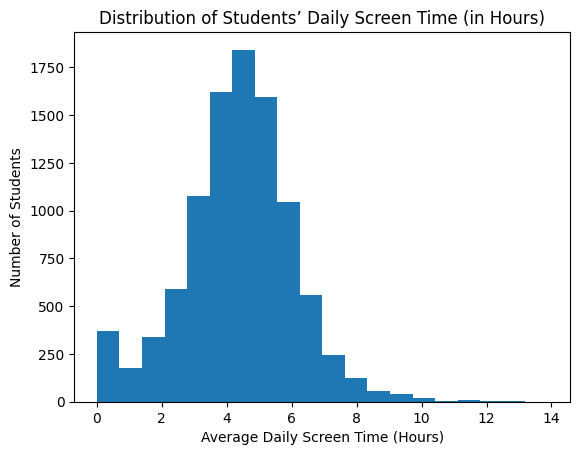

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
df = pd.read_csv("screensense_clean.csv")
plt.figure()
plt.hist(df["Avg_Daily_Screen_Time_hr"], bins=20)
plt.title("Distribution of Students’ Daily Screen Time (in Hours)")
plt.xlabel("Average Daily Screen Time (Hours)")
plt.ylabel("Number of Students")
plt.show()

Insight:

Most students spend between 3–6 hours daily on screens.
There are some extreme users with very high screen time (>10 hours), indicating potential overuse.

2.Age Band Distribution (Bar Chart)

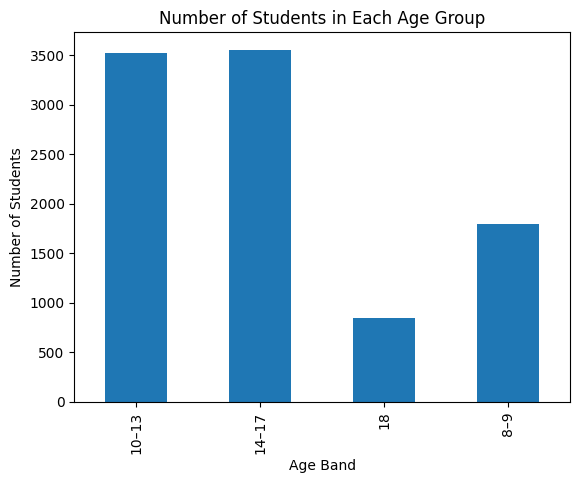

In [2]:
plt.figure()
df["age_band"].value_counts().sort_index().plot(kind="bar")
plt.title("Number of Students in Each Age Group")
plt.xlabel("Age Band")
plt.ylabel("Number of Students")
plt.show()

Majority of students fall in the 10–13 and 14–17 age groups, showing dataset is concentrated around middle and high school students.

3.Primary Device Usage (Bar Chart)

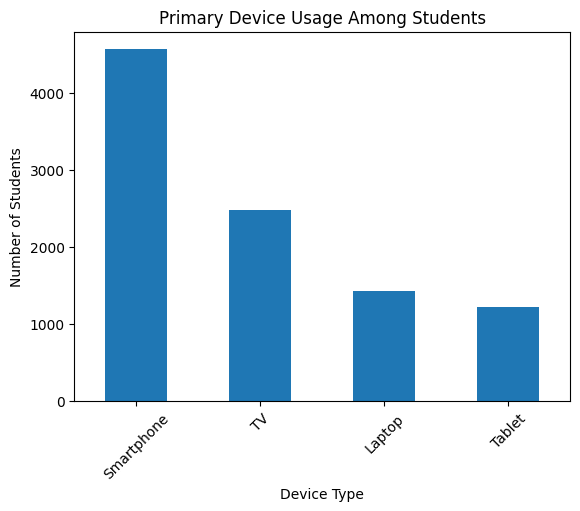

In [ ]:
plt.figure()
df["Primary_Device"].value_counts().plot(kind="bar")
plt.title("Primary Device Usage Among Students")
plt.xlabel("Device Type")
plt.ylabel("Number of Students")
plt.xticks(rotation=45)
plt.show()

Mobile phones are likely the most used device, indicating portability and accessibility drive screen exposure.

BIVARIATE ANALYSIS

1.Age Band vs Average Screen Time (Bar Chart)

In [18]:
df["age_band"] = pd.Categorical(
    df["age_band"],
    categories=["8–9", "10–13", "14–17", "18"],
    ordered=True
)

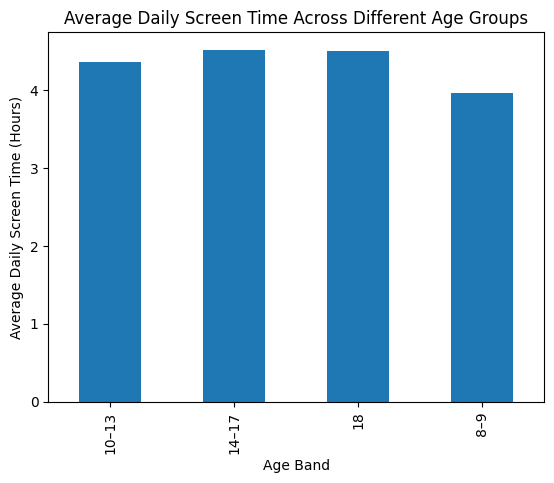

In [3]:
plt.figure()

df.groupby("age_band")["Avg_Daily_Screen_Time_hr"] \
.mean() \
  .sort_index() \
  .plot(kind="bar")

plt.title("Average Daily Screen Time Across Different Age Groups")
plt.xlabel("Age Band")
plt.ylabel("Average Daily Screen Time (Hours)")
plt.show()

Screen time increases with age. Older students (14–17) tend to spend more time on screens compared to younger groups.

2.Gender vs Average Screen Time (Boxplot)

<Figure size 640x480 with 0 Axes>

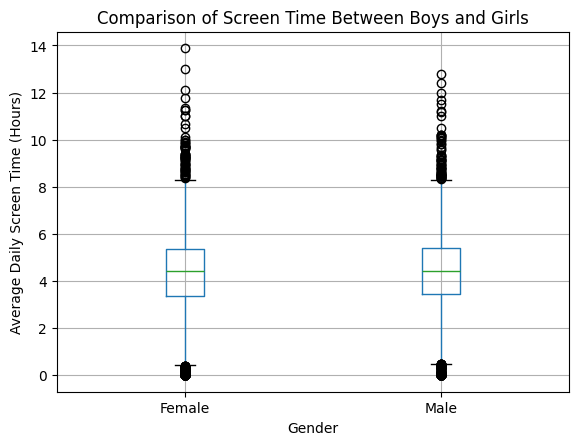

In [4]:
plt.figure()
df.boxplot(column="Avg_Daily_Screen_Time_hr", by="Gender")
plt.title("Comparison of Screen Time Between Boys and Girls")
plt.suptitle("")
plt.xlabel("Gender")
plt.ylabel("Average Daily Screen Time (Hours)")
plt.show()

The median screen time is similar across genders, but female gender may show slightly higher variability or extreme usage.

3.Urban vs Rural vs Screen Time (Bar Chart)

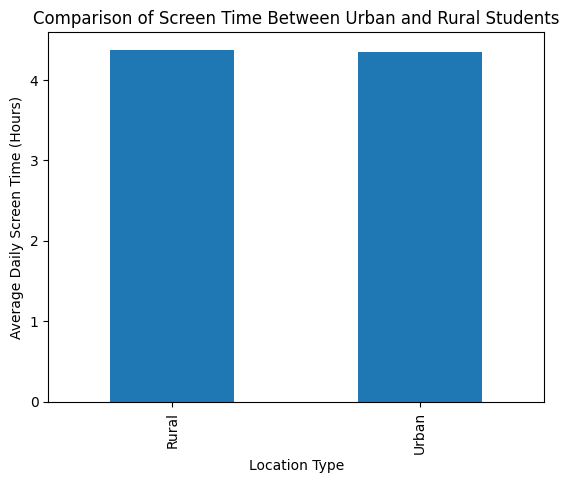

In [5]:
plt.figure()
df.groupby("Urban_or_Rural")["Avg_Daily_Screen_Time_hr"].mean().plot(kind="bar")
plt.title("Comparison of Screen Time Between Urban and Rural Students")
plt.xlabel("Location Type")
plt.ylabel("Average Daily Screen Time (Hours)")
plt.show()

In [23]:
df.groupby("Urban_or_Rural")["Avg_Daily_Screen_Time_hr"].mean()

Urban_or_Rural
Rural    4.373702
Urban    4.344123
Name: Avg_Daily_Screen_Time_hr, dtype: float64

The average screen time between rural (4.37 hours) and urban (4.34 hours) students differs by less than 2 minutes. This indicates that geographic location does not significantly influence daily screen usage in this dataset.

Screen Time by Primary Device
Bar Chart (Mean Hours)

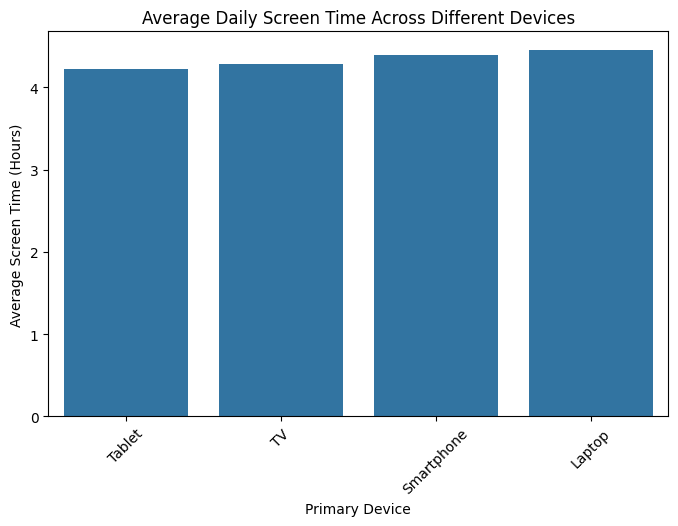

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))

device_avg = df.groupby('Primary_Device')['Avg_Daily_Screen_Time_hr'].mean().sort_values()

sns.barplot(x=device_avg.index, y=device_avg.values)

plt.title("Average Daily Screen Time Across Different Devices")
plt.xlabel("Primary Device")
plt.ylabel("Average Screen Time (Hours)")
plt.xticks(rotation=45)

plt.show()

Boxplot (Distribution)

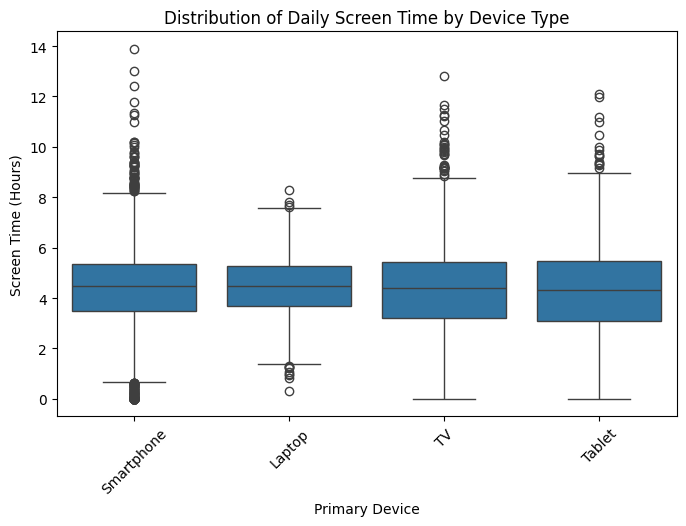

In [7]:
plt.figure(figsize=(8,5))

sns.boxplot(x='Primary_Device', y='Avg_Daily_Screen_Time_hr', data=df)

plt.title("Distribution of Daily Screen Time by Device Type")
plt.xlabel("Primary Device")
plt.ylabel("Screen Time (Hours)")
plt.xticks(rotation=45)

plt.show()

% Exceeding Recommended Limit by Device

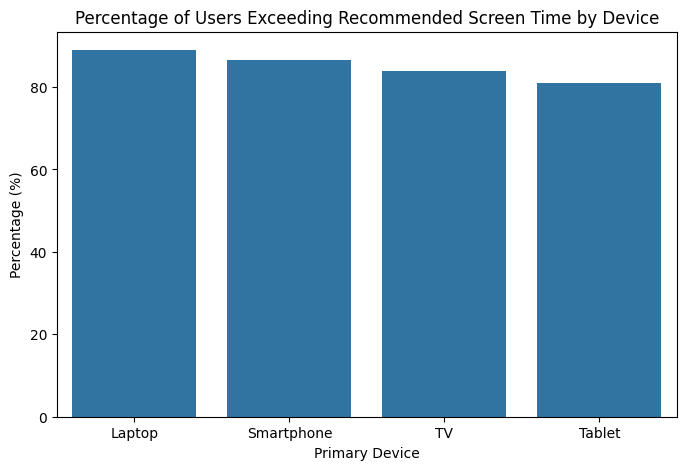

In [8]:
exceed_percent = df.groupby('Primary_Device')['Exceeded_Recommended_Limit'].mean()*100

plt.figure(figsize=(8,5))

sns.barplot(x=exceed_percent.index, y=exceed_percent.values)

plt.title("Percentage of Users Exceeding Recommended Screen Time by Device")
plt.xlabel("Primary Device")
plt.ylabel("Percentage (%)")

plt.show()

Usage Balance by Age Band

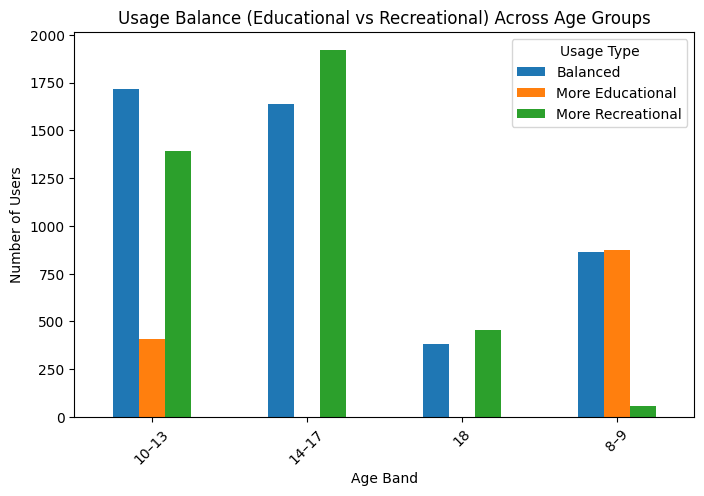

In [9]:
usage_age = pd.crosstab(df['age_band'], df['Usage_Balance'])

usage_age.plot(kind='bar', figsize=(8,5))

plt.title("Usage Balance (Educational vs Recreational) Across Age Groups")
plt.xlabel("Age Band")
plt.ylabel("Number of Users")
plt.xticks(rotation=45)

plt.legend(title="Usage Type")

plt.show()

Screen Time vs Health Impact

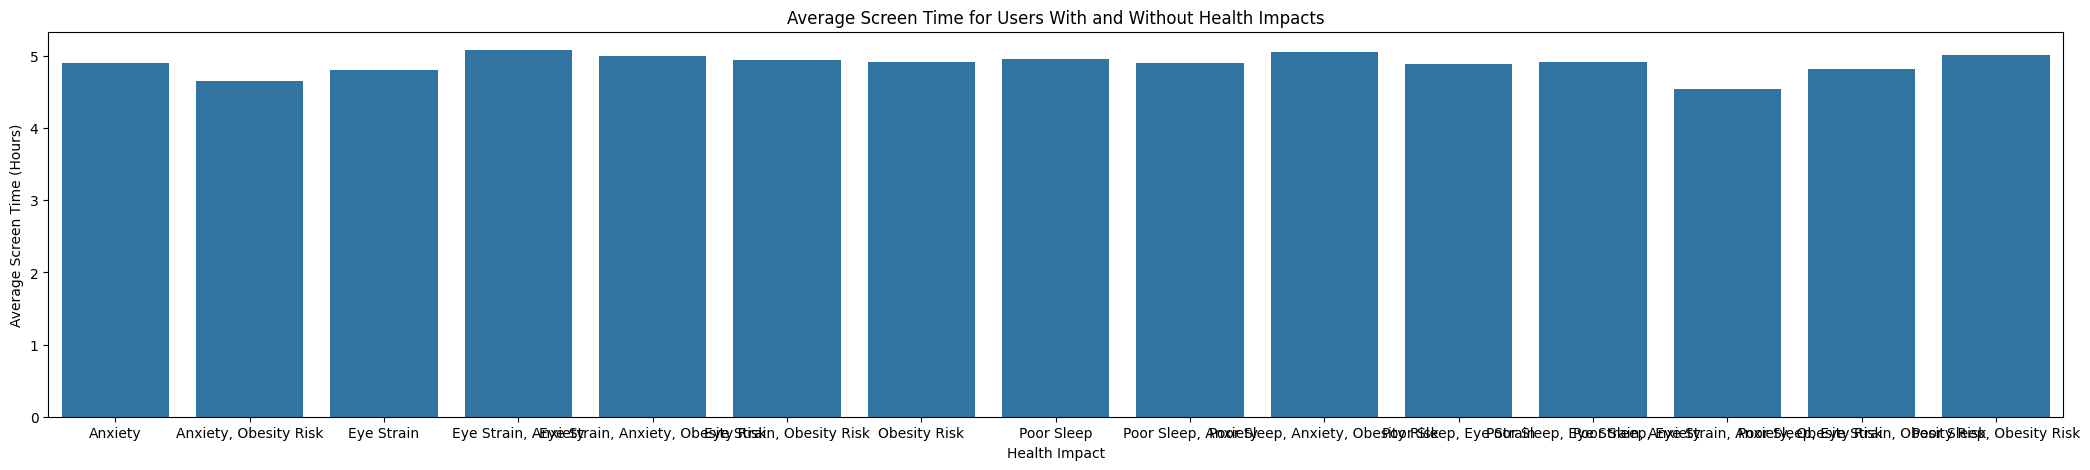

In [13]:
health_screen = df.groupby('Health_Impacts')['Avg_Daily_Screen_Time_hr'].mean()

plt.figure(figsize=(26,5))

sns.barplot(x=health_screen.index, y=health_screen.values)

plt.title("Average Screen Time for Users With and Without Health Impacts")
plt.xlabel("Health Impact")
plt.ylabel("Average Screen Time (Hours)")

plt.show()

Age Band × Device Analysis(Heatmap)


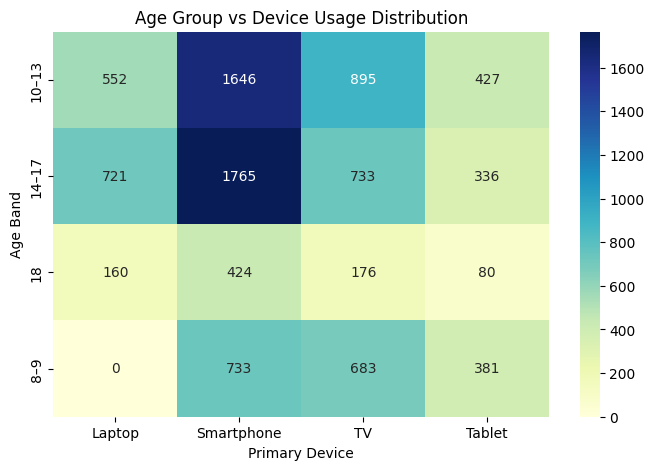

In [14]:

age_device = pd.crosstab(df['age_band'], df['Primary_Device'])

plt.figure(figsize=(8,5))
sns.heatmap(age_device, annot=True, fmt='d', cmap='YlGnBu')

plt.title("Age Group vs Device Usage Distribution")
plt.xlabel("Primary Device")
plt.ylabel("Age Band")

plt.show()

Gender × Screen Time Analysis
(Stacked Bar Chart)

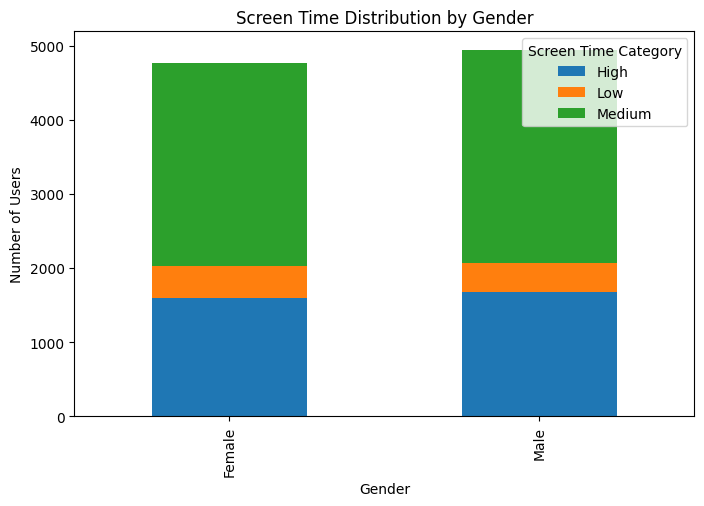

In [15]:
screen_gender = pd.crosstab(df['Gender'], df['screentime_bucket'])

screen_gender.plot(kind='bar', stacked=True, figsize=(8,5))

plt.title("Screen Time Distribution by Gender")
plt.xlabel("Gender")
plt.ylabel("Number of Users")

plt.legend(title="Screen Time Category")

plt.show()

Urban/Rural × Screen Time Analysis
(Stacked Bar Chart)

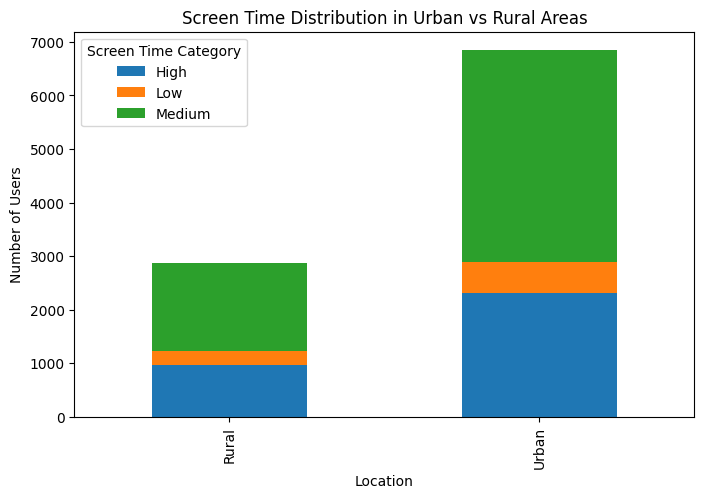

In [16]:
urban_screen = pd.crosstab(df['Urban_or_Rural'], df['screentime_bucket'])

urban_screen.plot(kind='bar', stacked=True, figsize=(8,5))

plt.title("Screen Time Distribution in Urban vs Rural Areas")
plt.xlabel("Location")
plt.ylabel("Number of Users")

plt.legend(title="Screen Time Category")

plt.show()

Health Impact vs Screen Time
(Cohort Comparison Plot)

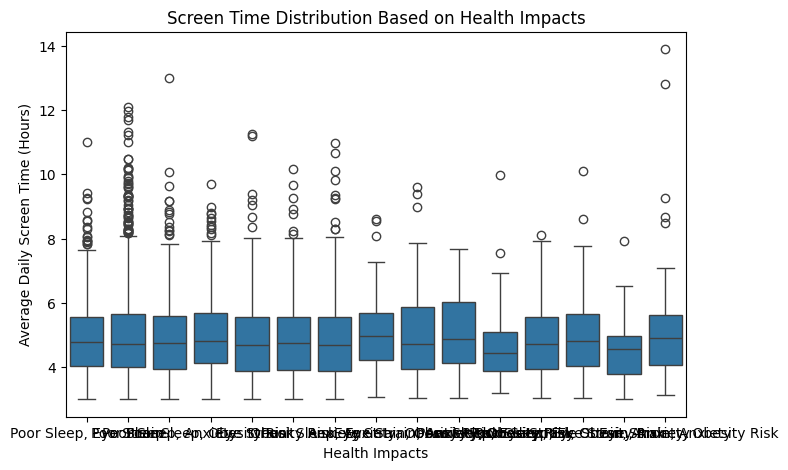

In [20]:
plt.figure(figsize=(8,5))

sns.boxplot(x='Health_Impacts', y='Avg_Daily_Screen_Time_hr', data=df)

plt.title("Screen Time Distribution Based on Health Impacts")
plt.xlabel("Health Impacts")
plt.ylabel("Average Daily Screen Time (Hours)")

plt.show()

Identify Highest Risk Cohort
(Age Band vs Health Impact Heatmap)

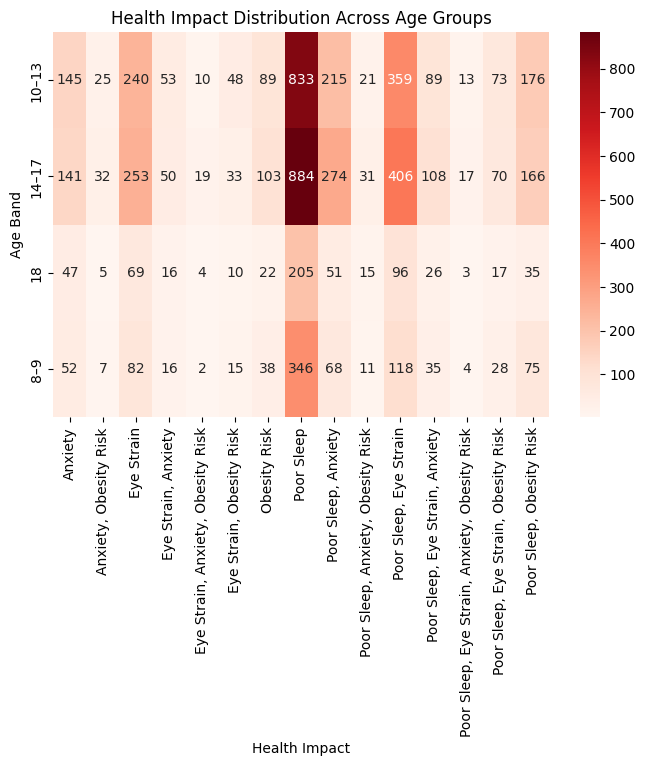

In [21]:
risk_cohort = pd.crosstab(df['age_band'], df['Health_Impacts'])

plt.figure(figsize=(8,5))
sns.heatmap(risk_cohort, annot=True, fmt='d', cmap='Reds')

plt.title("Health Impact Distribution Across Age Groups")
plt.xlabel("Health Impact")
plt.ylabel("Age Band")

plt.show()

Pivot Table: Age Band × Primary Device (Average Screen Time)

In [22]:
pivot_table = pd.pivot_table(
    df,
    values='Avg_Daily_Screen_Time_hr',
    index='age_band',
    columns='Primary_Device',
    aggfunc='mean'
)

print(pivot_table)

Primary_Device    Laptop  Smartphone        TV    Tablet
age_band                                                
10–13           4.432627    4.423919  4.251453  4.176112
14–17           4.466824    4.531632  4.543711  4.485863
18              4.515500    4.518821  4.467216  4.483125
8–9                  NaN    3.891583  4.014378  3.998766


Heatmap

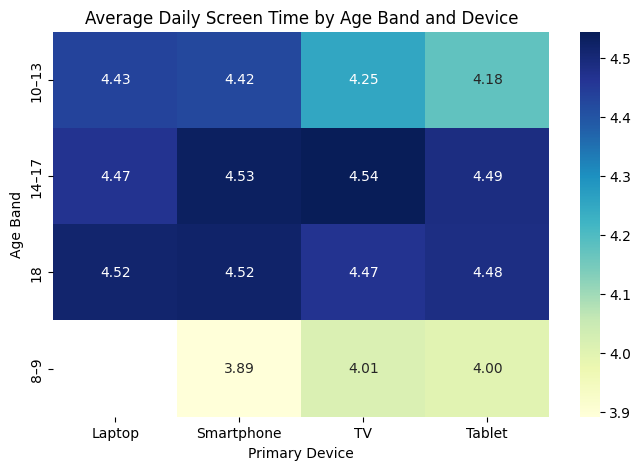

In [24]:


plt.figure(figsize=(8,5))

sns.heatmap(pivot_table, annot=True, cmap='YlGnBu', fmt='.2f')

plt.title("Average Daily Screen Time by Age Band and Device")
plt.xlabel("Primary Device")
plt.ylabel("Age Band")

plt.show()

Health Impact vs Screen Time by Age Band

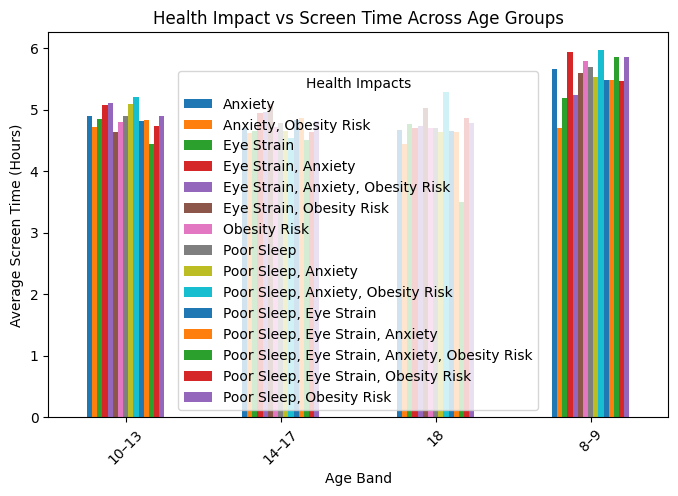

In [25]:
health_age = df.groupby(['age_band','Health_Impacts'])['Avg_Daily_Screen_Time_hr'].mean().unstack()

health_age.plot(kind='bar', figsize=(8,5))

plt.title("Health Impact vs Screen Time Across Age Groups")
plt.xlabel("Age Band")
plt.ylabel("Average Screen Time (Hours)")

plt.legend(title="Health Impacts")

plt.xticks(rotation=45)

plt.show()

Age Band × Device Heatmap

In [3]:
pivot_table = pd.pivot_table(
    df,
    values='Avg_Daily_Screen_Time_hr',
    index='age_band',
    columns='Primary_Device',
    aggfunc='mean'
)

print(pivot_table)

Primary_Device    Laptop  Smartphone        TV    Tablet
age_band                                                
10–13           4.432627    4.423919  4.251453  4.176112
14–17           4.466824    4.531632  4.543711  4.485863
18              4.515500    4.518821  4.467216  4.483125
8–9                  NaN    3.891583  4.014378  3.998766


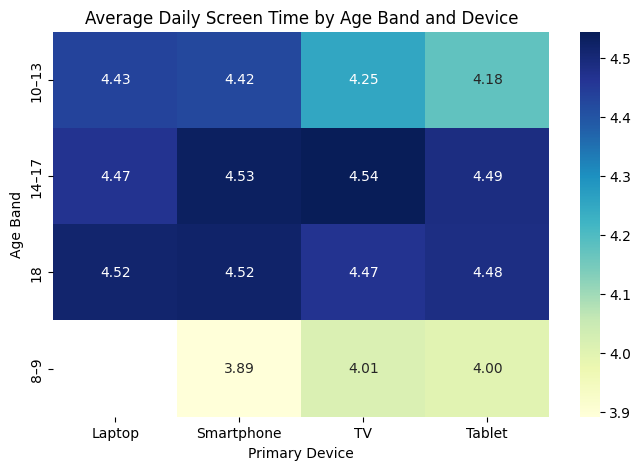

In [4]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

sns.heatmap(pivot_table, annot=True, cmap="YlGnBu", fmt=".2f")

plt.title("Average Daily Screen Time by Age Band and Device")
plt.xlabel("Primary Device")
plt.ylabel("Age Band")

plt.show()

Insights (write these)

1️⃣ Screen time varies across age groups and device types, indicating different device preferences among age bands.
2️⃣ Older age groups generally show higher screen time on personal devices like mobiles and laptops.

Screen Time vs Health Impact

In [5]:
df["Health_Risk_Flag"] = df["Health_Impacts"].apply(
    lambda x: "Risk" if x != "No Reported Issues" else "No Risk"
)

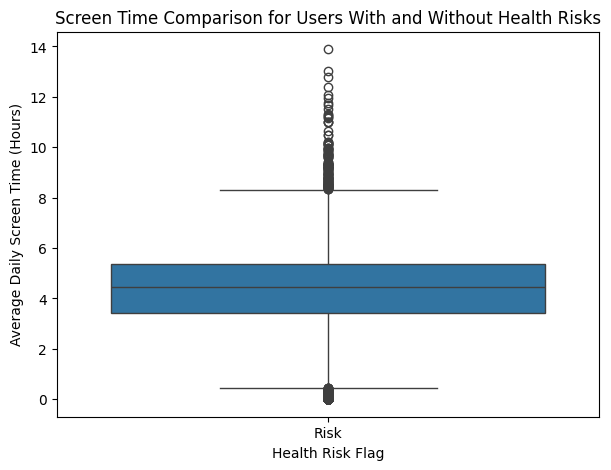

In [6]:
plt.figure(figsize=(7,5))

sns.boxplot(x="Health_Risk_Flag", y="Avg_Daily_Screen_Time_hr", data=df)

plt.title("Screen Time Comparison for Users With and Without Health Risks")
plt.xlabel("Health Risk Flag")
plt.ylabel("Average Daily Screen Time (Hours)")

plt.show()

Insights

1️⃣ Users reporting health risks tend to have slightly higher average screen time.
2️⃣ This suggests a possible association between prolonged screen exposure and health concerns, though it does not prove causation.

Urban vs Rural Screen Time

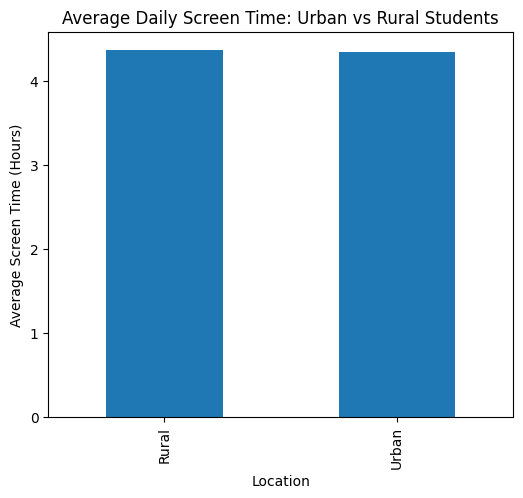

In [7]:
urban_rural_avg = df.groupby("Urban_or_Rural")["Avg_Daily_Screen_Time_hr"].mean()

plt.figure(figsize=(6,5))

urban_rural_avg.plot(kind="bar")

plt.title("Average Daily Screen Time: Urban vs Rural Students")
plt.xlabel("Location")
plt.ylabel("Average Screen Time (Hours)")

plt.show()

Insights

1️⃣ Urban and rural students show very similar average screen time levels.
2️⃣ This suggests digital device usage is widespread across both locations.

Age Band vs Exceeded Screen Limit

In [8]:
exceed_percent = df.groupby("age_band")["Exceeded_Recommended_Limit"].mean() * 100

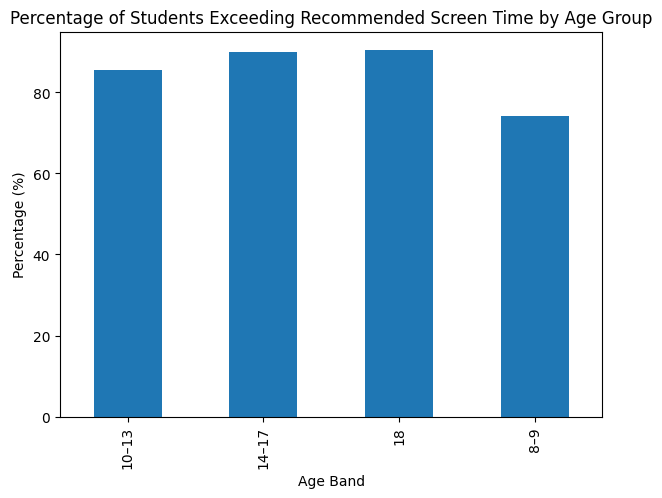

In [9]:
plt.figure(figsize=(7,5))

exceed_percent.plot(kind="bar")

plt.title("Percentage of Students Exceeding Recommended Screen Time by Age Group")
plt.xlabel("Age Band")
plt.ylabel("Percentage (%)")

plt.show()

Insights

1️⃣ The percentage of students exceeding recommended screen time increases in older age groups.
2️⃣ This indicates teenagers may be more prone to excessive screen usage compared to younger children.

Age Group vs Screen Time grouped by Device
(Multivariate Plot)

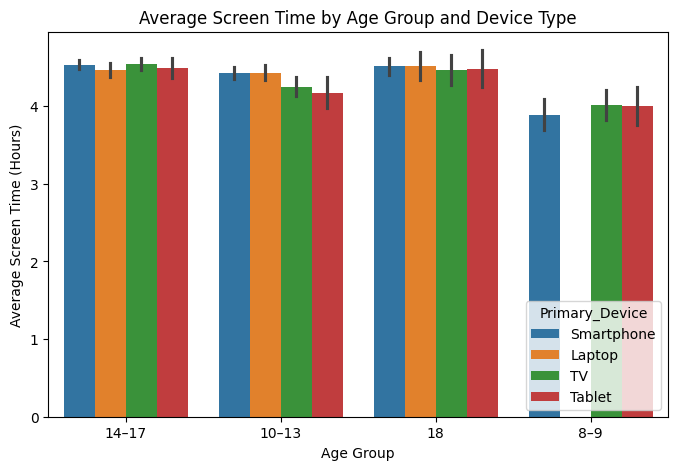

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

sns.barplot(
    data=df,
    x="age_band",
    y="Avg_Daily_Screen_Time_hr",
    hue="Primary_Device"
)

plt.title("Average Screen Time by Age Group and Device Type")
plt.xlabel("Age Group")
plt.ylabel("Average Screen Time (Hours)")

plt.show()

Insights

Screen time varies across age groups and device types.

Some devices show higher screen usage within specific age groups.

Gender vs Screen Time grouped by Device

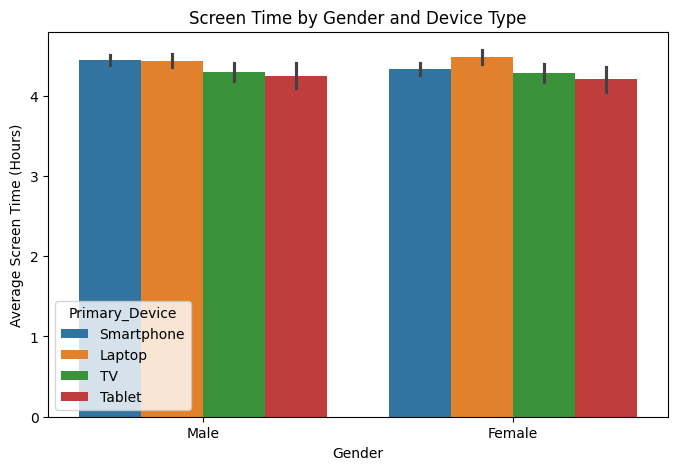

In [11]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=df,
    x="Gender",
    y="Avg_Daily_Screen_Time_hr",
    hue="Primary_Device"
)

plt.title("Screen Time by Gender and Device Type")
plt.xlabel("Gender")
plt.ylabel("Average Screen Time (Hours)")

plt.show()

Insights

Screen time patterns are similar across genders but vary by device usage.

Certain devices contribute more to higher daily screen hours.

Urban/Rural vs Screen Time grouped by Device

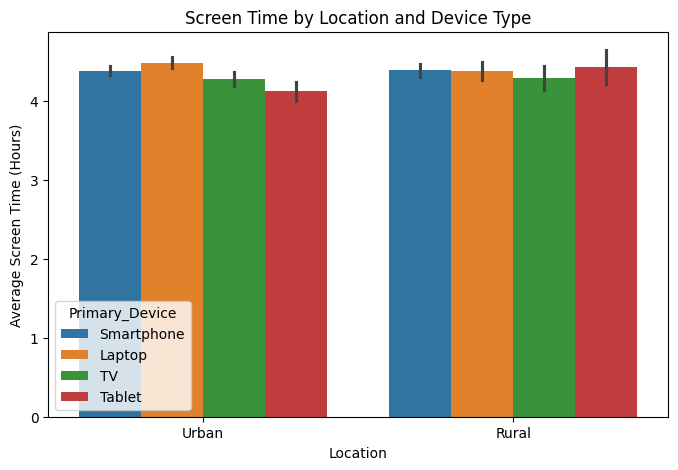

In [12]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=df,
    x="Urban_or_Rural",
    y="Avg_Daily_Screen_Time_hr",
    hue="Primary_Device"
)

plt.title("Screen Time by Location and Device Type")
plt.xlabel("Location")
plt.ylabel("Average Screen Time (Hours)")

plt.show()

Insights

Screen usage patterns are similar between urban and rural users, but device preference differs.

Certain devices may contribute to higher usage across locations.

Screen Time vs Health Impacts

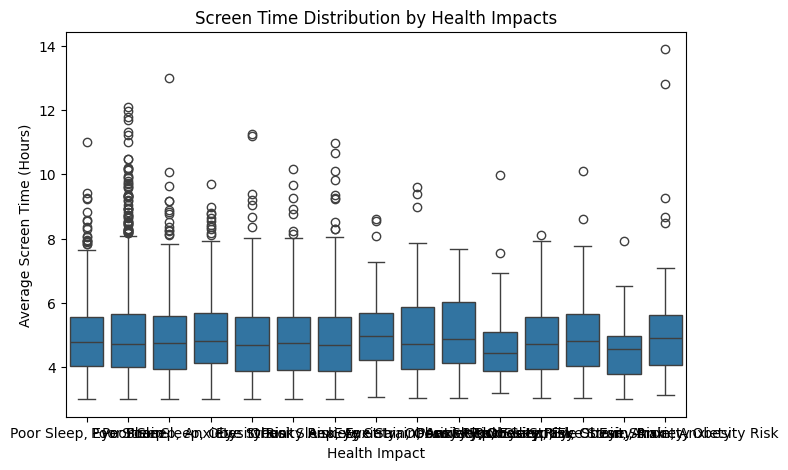

In [13]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="Health_Impacts",
    y="Avg_Daily_Screen_Time_hr"
)

plt.title("Screen Time Distribution by Health Impacts")
plt.xlabel("Health Impact")
plt.ylabel("Average Screen Time (Hours)")

plt.show()

Age Group vs Exceeded Limit

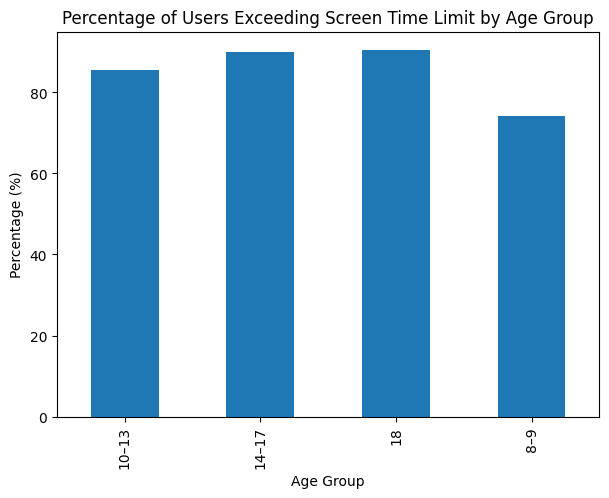

In [14]:
exceed_age = df.groupby("age_band")["Exceeded_Recommended_Limit"].mean()*100

plt.figure(figsize=(7,5))

exceed_age.plot(kind="bar")

plt.title("Percentage of Users Exceeding Screen Time Limit by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Percentage (%)")

plt.show()

Insights

Older age groups tend to exceed recommended screen time more frequently.

This suggests increased screen dependency among teenagers.

Device vs Exceeded Limit

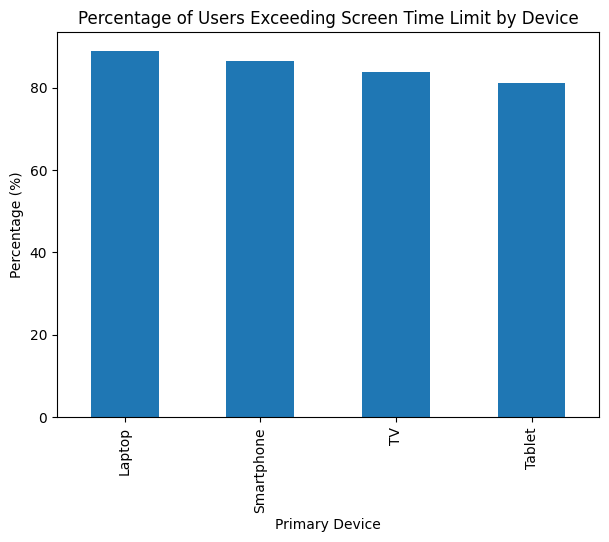

In [15]:
exceed_device = df.groupby("Primary_Device")["Exceeded_Recommended_Limit"].mean()*100

plt.figure(figsize=(7,5))

exceed_device.plot(kind="bar")

plt.title("Percentage of Users Exceeding Screen Time Limit by Device")
plt.xlabel("Primary Device")
plt.ylabel("Percentage (%)")

plt.show()

Insights

Some devices are associated with higher probability of exceeding recommended screen time.

Portable personal devices tend to encourage longer usage durations.